In [1]:
%cd ..
from helpers.helpersGeneration import *
from helpers.helpersSimulation import *
from helpers.helpersTracking import *
from helpers.helpersStatistics import *
from helpers.helpersAssignment import *

c:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking


In [2]:
# slow, medium and fast particles
D_list = [
    (0.10, 0.25),
    (0.50, 0.20),
    (1.50, 0.25),
    (3.00, 0.20),
    (5.00, 0.10),
]

simulation_config = {
    "nparticles": 14, # below 20 for this comparison, to avoid dominance of overlaps and assignment errors
    "nframes": 60,
    "nposframe": 5,
    "D_list": D_list,
    "dt": 1.0,
    "anisotropy_ratio_range": (1.0, 1.0),
    "theta_range": (np.deg2rad(30), np.deg2rad(30)),
    "frame_size": (128, 128),
    "intensity_mean": 800,
    "intensity_std": 150,
}

image_config = {
    "particle_intensity": [800, 150],
    "background_intensity": [100, 30],
    "poisson_noise": 100,
    "output_size": 128,
    "upsampling_factor": 5,
    "resolution": 100e-9,
    "trajectory_unit": -1,
    "invert_y": True,
}

sim = Simulator(
    simulation_config=simulation_config,
    image_config=image_config,
    seed=42,
).run()

frames = sim.frames
trajectories_HR = sim.trajectories_HR # high-resolution trajectories with size nframes x nposframe
trajectories_GT = sim.trajectories_GT # Ground-Truth, low-resolution trajectories with size nframes
trajectories_FR = sim.trajectories_FR # low-resolution trajectories with size nframes, with diffusion data computed from GT
video_aniso = sim.video

In [3]:
sim.animate(interval=100, cmap="gray")

In [4]:
# define custom cost function for peak-to-peak assignment: separate weights between distance, intensity and sigma
peak2peak_cost = PeakToPeak(
    terms={
        "distance": DistanceTerm(weight=0.5, norm=image_config["output_size"]/10),
        "intensity": IntensityTerm(weight=0.5, norm=image_config["particle_intensity"][0]+image_config["particle_intensity"][1]),
    }
)

# define custom cost function for trajectory-to-trajectory assignment: fully weighted on distance between trajectories
traj_cost = TrajToTraj(
    terms={
        "position": MeanPositionDistanceTerm(weight=0.8, norm=1.0),
        "length": LengthDifferenceTerm(weight=0.1, norm=10),
        "start_frame": StartFrameDifferenceTerm(weight=0.1, norm=5),
    }
)

In [5]:
detection_results = sim.track(
    mode="detection",
    detection_threshold=400,
    max_distance=8,
    min_length=8,
    r_squared_threshold=0.45,
    algo_peak2peak="hungarian",
    cost_func_peak2peak=peak2peak_cost,
    algo_traj2traj="hungarian",
    cost_func_traj2traj=traj_cost,
    verbose_loc=False,
    visualization_loc=False,
    verbose_assignment=False,
)

In [6]:
localization_results = sim.track(
    mode="localization",
    detection_threshold=400,
    max_distance=8,
    min_length=8,
    r_squared_threshold=0.45,
    cost_func_peak2peak=peak2peak_cost,
    cost_func_traj2traj=traj_cost
)

In [7]:
trajectories_detection = detection_results[0]
trajectories_localization = localization_results[0]

### Core Detection vs Localization Comparison

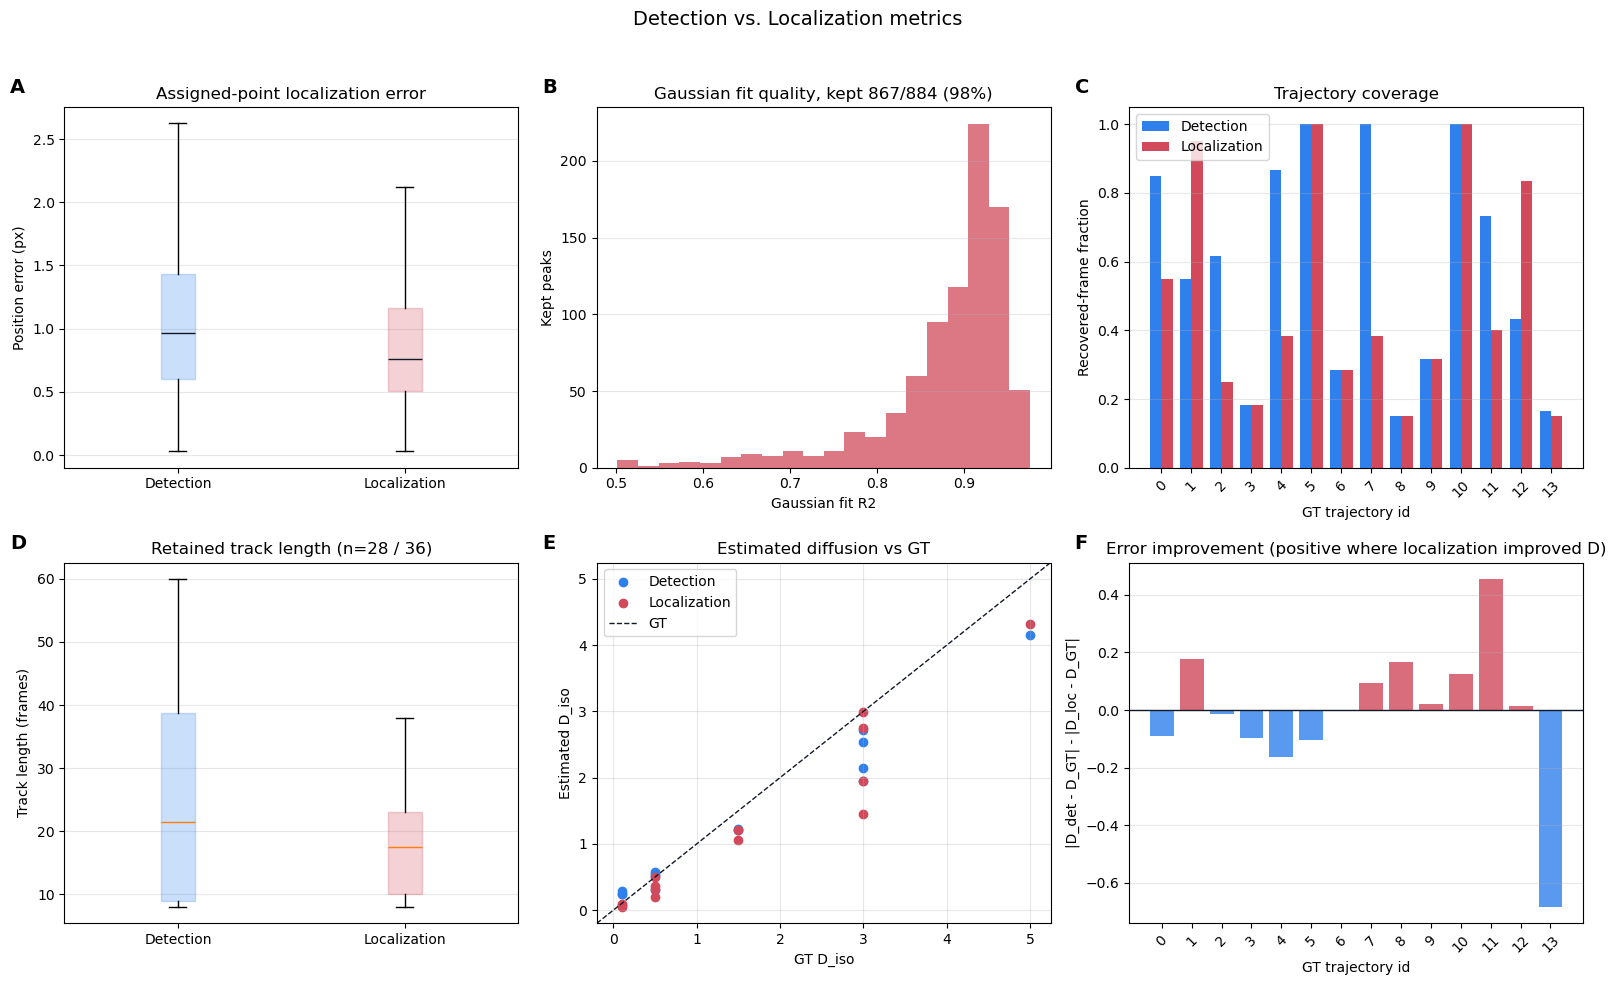

{'detection': {'n_tracks': 28,
  'n_assigned': 14,
  'n_unassigned': 14,
  'median_position_error_px': 0.9638630504993427,
  'mean_coverage': 0.5821428571428572,
  'median_track_length': 21.5,
  'MAE_D_iso': 0.3474967377076963},
 'localization': {'n_tracks': 36,
  'n_assigned': 14,
  'n_unassigned': 22,
  'median_position_error_px': 0.7582224779962388,
  'mean_coverage': 0.48809523809523814,
  'median_track_length': 17.5,
  'MAE_D_iso': 0.3547540743494532}}

In [8]:
peaks_detection_diag = extract_peaks(
    frames,
    mode="detection",
    detection_threshold=400,
)

peaks_localization_diag = extract_peaks(
    frames,
    mode="localization",
    detection_threshold=400,
    r_squared_threshold=0.5,
    verbose_loc=False,
    visualization_loc=False,
)

det_vs_loc_summary = plot_det_vs_loc_core_figure(
    trajectories_GT,
    trajectories_detection,
    trajectories_localization,
    peaks_detection=peaks_detection_diag,
    peaks_localization=peaks_localization_diag,
    dt=simulation_config["dt"],
    tau=1,
    title='Detection vs. Localization metrics',
    return_summary=True,
)

det_vs_loc_summary

### MSD Evaluation

In [9]:
MSD_GT = calculateMSDtrajectories(trajectories_GT)
MSD_FR = calculateMSDtrajectories(trajectories_FR)
MSD_detection = calculateMSDtrajectories(trajectories_detection)
MSD_localization = calculateMSDtrajectories(trajectories_localization)

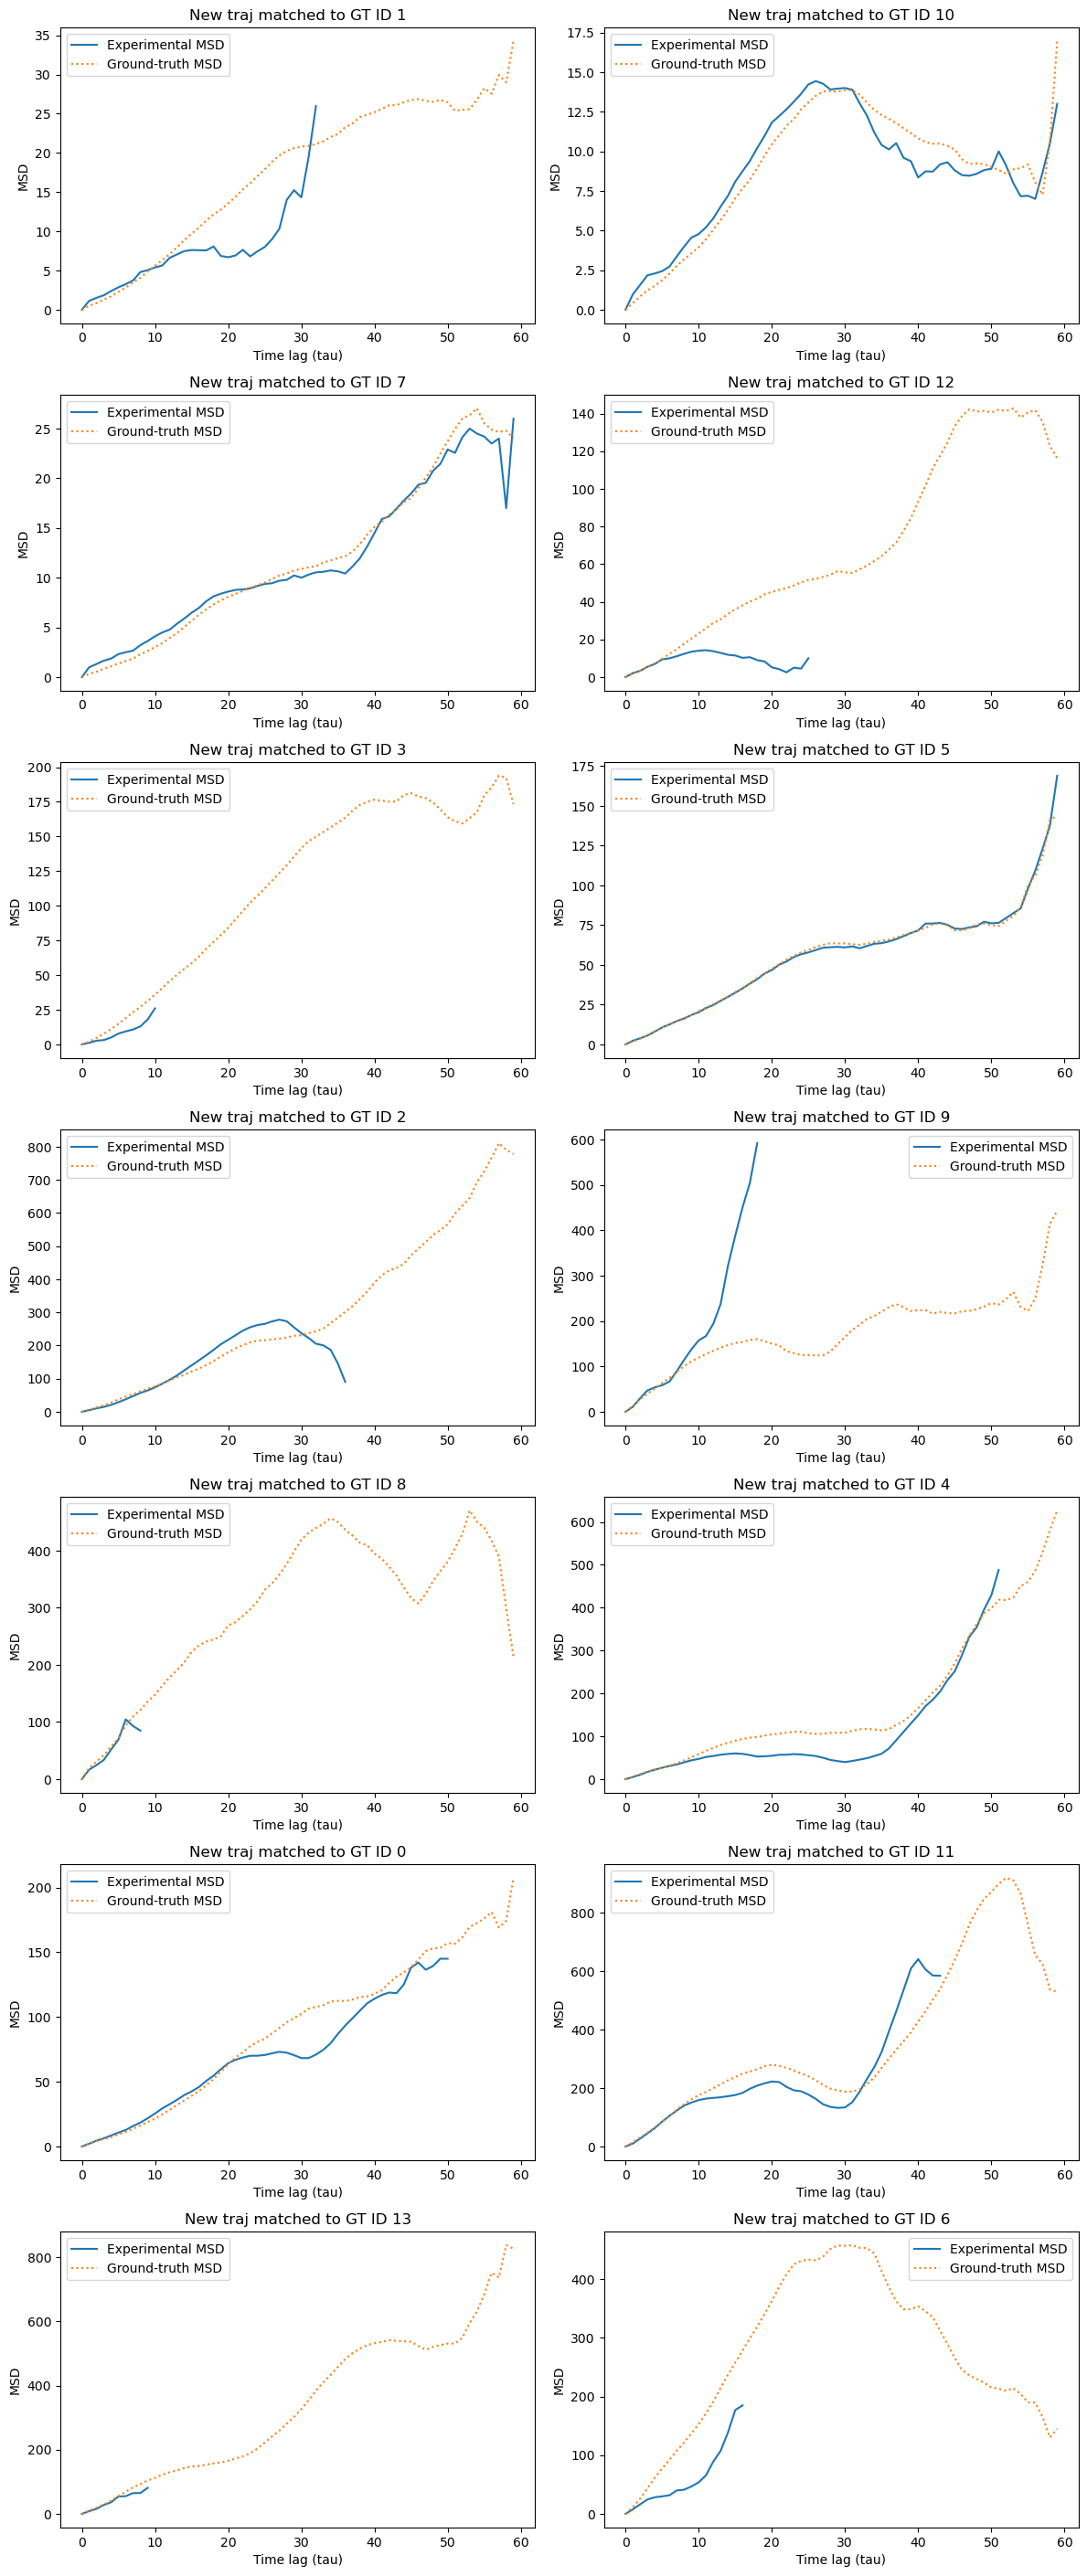

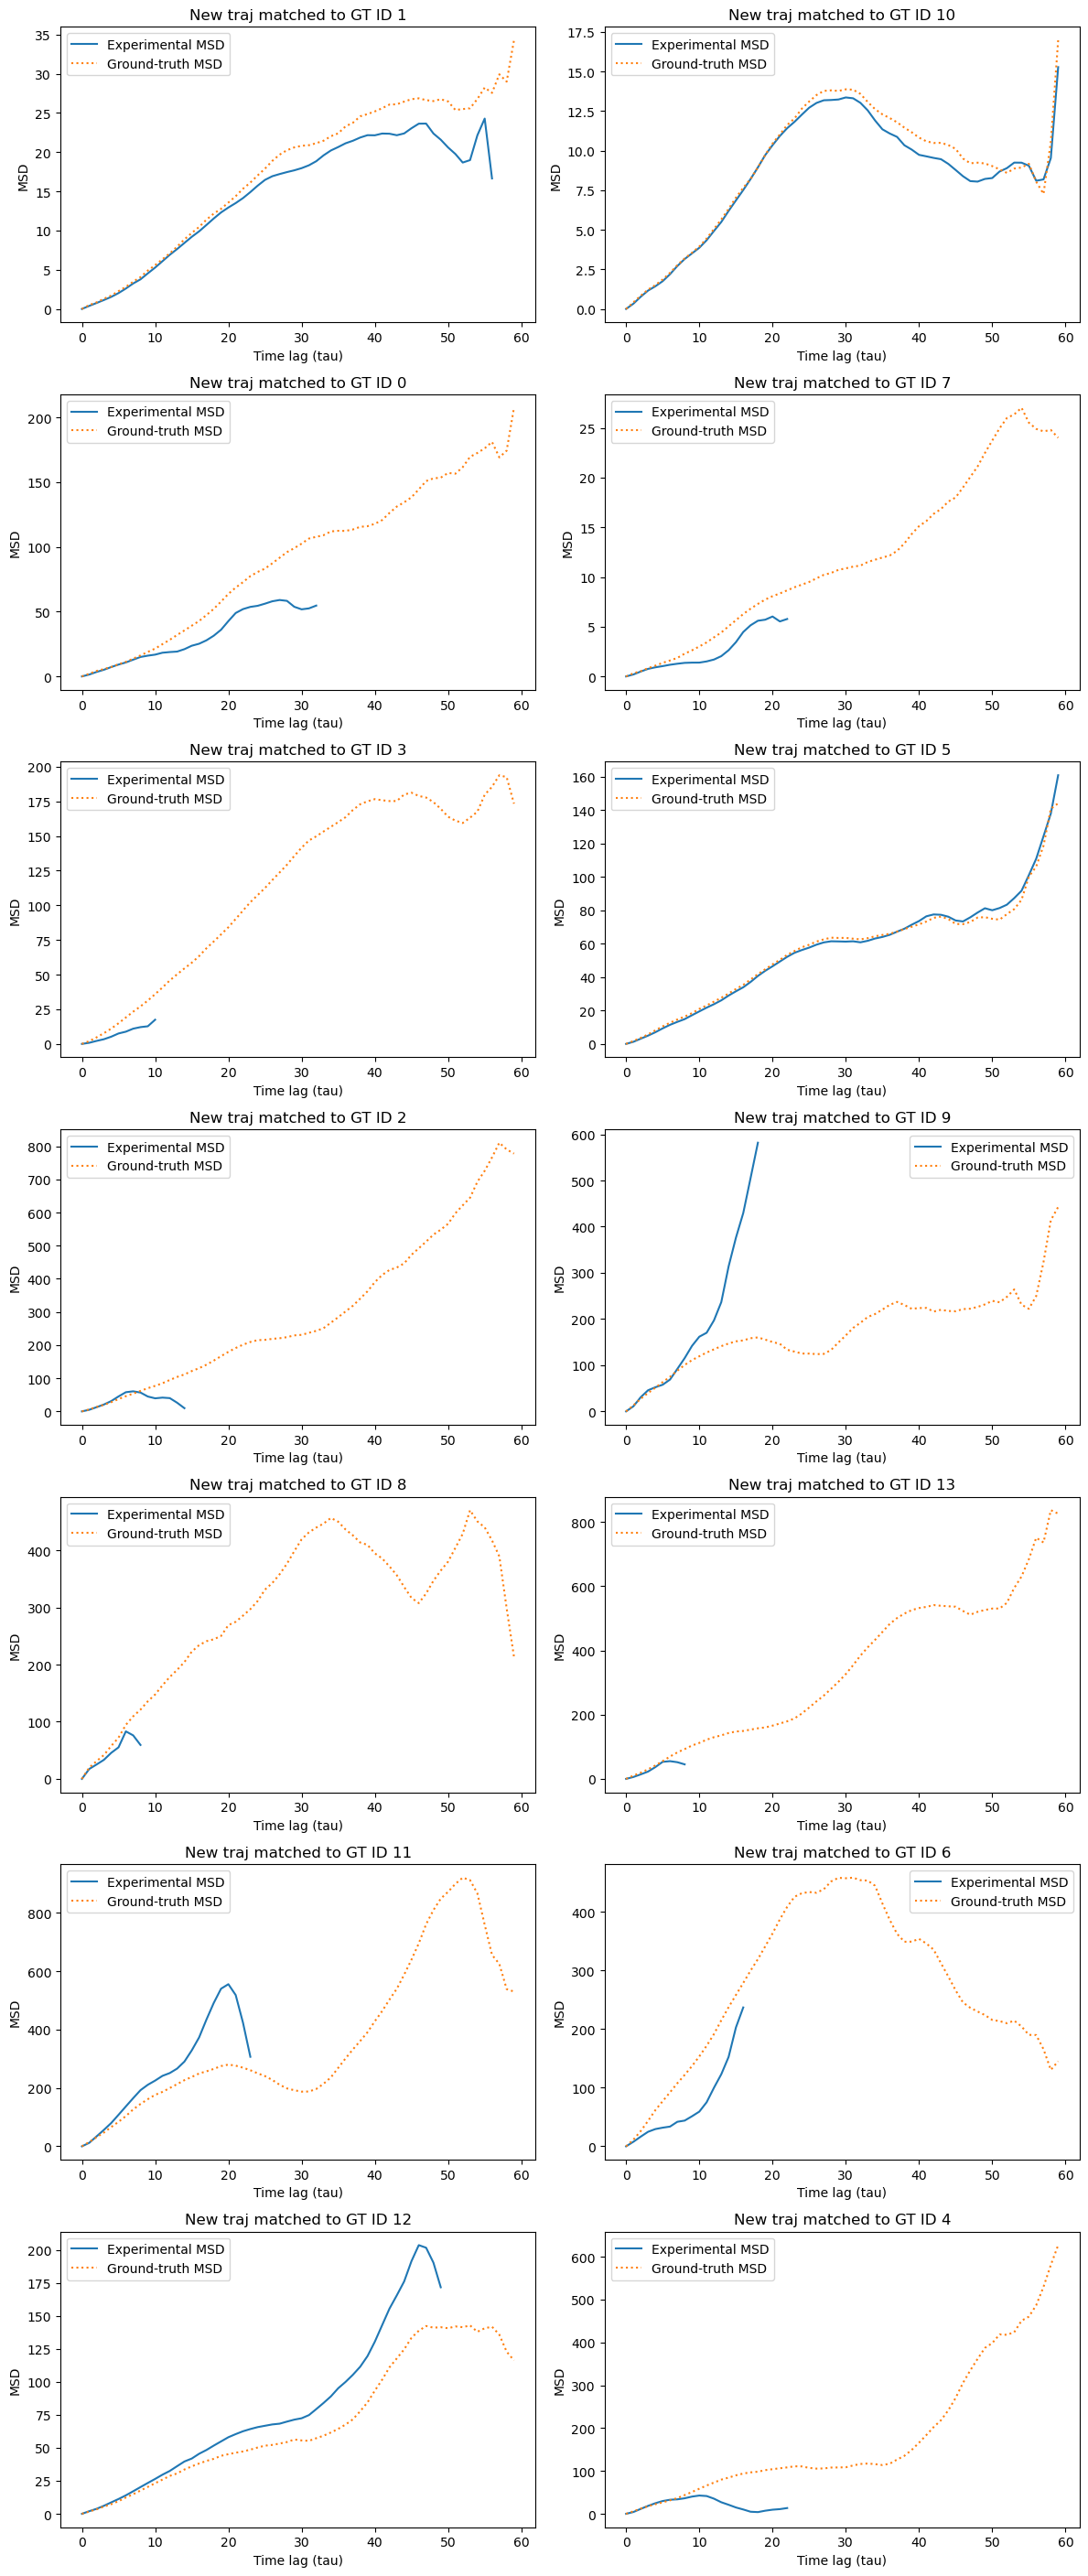

In [10]:
plotMSDvsGT(trajectories_detection, trajectories_GT)
plotMSDvsGT(trajectories_localization, trajectories_GT)

### D Evaluation

In [11]:
D_results_FR = estimateDfromTrajectories(trajectories_FR)
D_results_detection = estimateDfromTrajectories(trajectories_detection)
D_results_localization = estimateDfromTrajectories(trajectories_localization)

In [12]:
# results.append({
#             "id": traj.id,
#             "D1": D1,
#             "D2": D2,
#             "theta": theta,
#             "anisotropy": D2 / D1 if np.isfinite(D1) and D1 > 0 else np.nan,
#             "D_tensor": D_tensor,
#         })

In [13]:
traj_list = [trajectories_GT, trajectories_FR, trajectories_detection, trajectories_localization]
labels = ["GT", "FR", "Detection", "Localization"]

In [14]:
def plotDcomparison(trajectories_list, labels):
    D1_list = []
    D2_list = []
    for trajs in trajectories_list:
        D1, D2, _ = get_traj_params(trajs)
        D1_list.append(D1)
        D2_list.append(D2)
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.boxplot(D1_list, labels=labels)
    plt.title("D1 comparison")
    plt.ylabel("D1 (µm²/s)")
    
    plt.subplot(1, 2, 2)
    plt.boxplot(D2_list, labels=labels)
    plt.title("D2 comparison")
    plt.ylabel("D2 (µm²/s)")
    
    plt.tight_layout()
    plt.show()

C:\Users\armel\AppData\Local\Temp\ipykernel_18568\386189727.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(D1_list, labels=labels)
C:\Users\armel\AppData\Local\Temp\ipykernel_18568\386189727.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(D2_list, labels=labels)


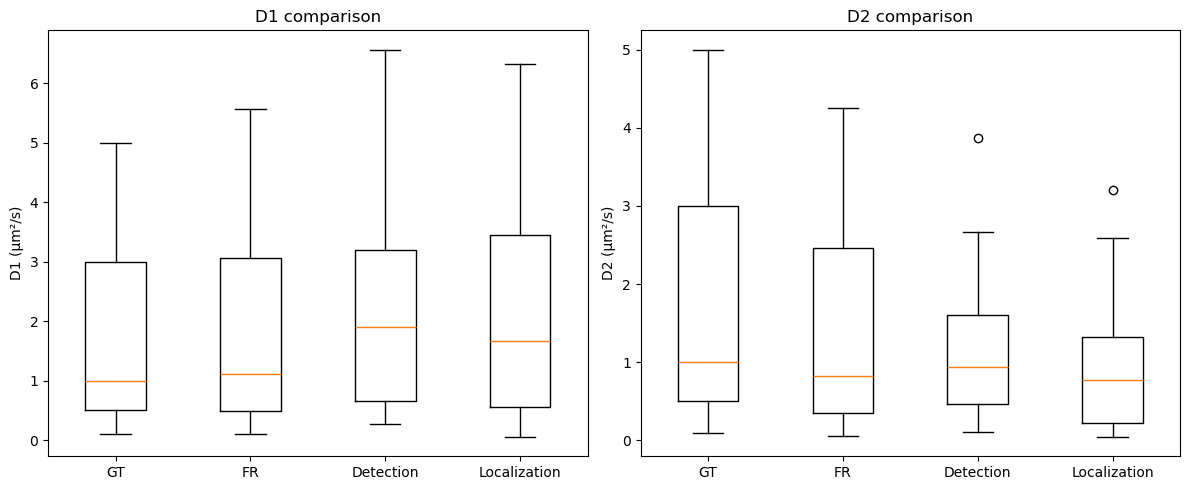

In [15]:
plotDcomparison(traj_list, labels)

In [16]:
print(trajectories_GT[3].MSD)

[  0.           1.9862091    4.71480289   7.72653301  11.01635091
  14.8887586   19.06117936  23.24865379  27.07699803  31.27448396
  35.89158328  40.70661167  45.78062664  50.2018461   54.47975592
  58.56903574  63.31551866  68.97133206  73.87478336  78.98886141
  84.15926132  90.14167246  96.20461722 102.22904123 107.35544859
 112.48034472 118.20737946 123.69930243 129.24860455 135.57343193
 141.56404042 146.76459543 149.74098732 153.25310763 156.62870532
 159.99981042 163.56098662 168.74003495 172.88495807 175.01115482
 176.58089213 175.76941185 175.18228874 175.21168843 179.9216295
 181.22781198 178.86883516 177.71401812 174.44295741 169.57133833
 163.88633421 161.05711819 159.36328205 163.18350787 167.5154902
 179.74755254 185.46797769 193.81840371 192.43650784 173.32015748]


In [17]:
def plotMSD_multi(trajectories_lists, labels):
    """
    Plot superimposed MSD curves for multiple trajectory lists.
    
    Parameters
    ----------
    trajectories_lists : list of lists
        A list where each element is a list of trajectories.
        Each trajectory must have:
            - traj.id : unique identifier (int or similar)
            - traj.MSD : array-like or None
    labels : list of str
        Labels corresponding to each trajectories list.
    
    Behavior
    --------
    - For each trajectory ID that appears in ANY list,
      plot all available MSD curves on the same subplot.
    - One subplot per trajectory ID.
    - Only plot MSD curves that exist and are non-empty.
    """

    # --- Build mapping: list_index -> {id -> trajectory} ---
    maps = []
    for trajs in trajectories_lists:
        maps.append({traj.id: traj for traj in trajs if traj.id is not None})

    # --- Collect all unique IDs across all lists ---
    all_ids = set()
    for m in maps:
        all_ids |= set(m.keys())

    if len(all_ids) == 0:
        print("No trajectories with valid IDs found.")
        return

    all_ids = sorted(all_ids)

    # --- Prepare figure layout ---
    n = len(all_ids)
    ncols = 2
    nrows = math.ceil(n / ncols)

    plt.figure(figsize=(12, 4 * nrows))

    # --- Loop over each trajectory ID ---
    for i, tid in enumerate(all_ids):
        plt.subplot(nrows, ncols, i + 1)
        plt.title(f"Trajectory ID {tid}")

        plotted_any = False

        # Loop over each list and label
        for traj_list_idx, (m, label) in enumerate(zip(maps, labels)):
            if tid in m:
                MSD = m[tid].MSD
                if MSD is not None and len(MSD) > 0:
                    plt.plot(MSD, label=label)
                    plotted_any = True

        if not plotted_any:
            plt.text(0.5, 0.5, "No MSD available", ha="center", va="center")

        plt.xlabel("Time lag (tau)")
        plt.ylabel("MSD")
        plt.legend()

    plt.tight_layout()
    plt.show()


In [18]:
traj_list3 = [ trajectories_FR, trajectories_detection, trajectories_localization]
labels = ["FR", "Detection", "Localization"]

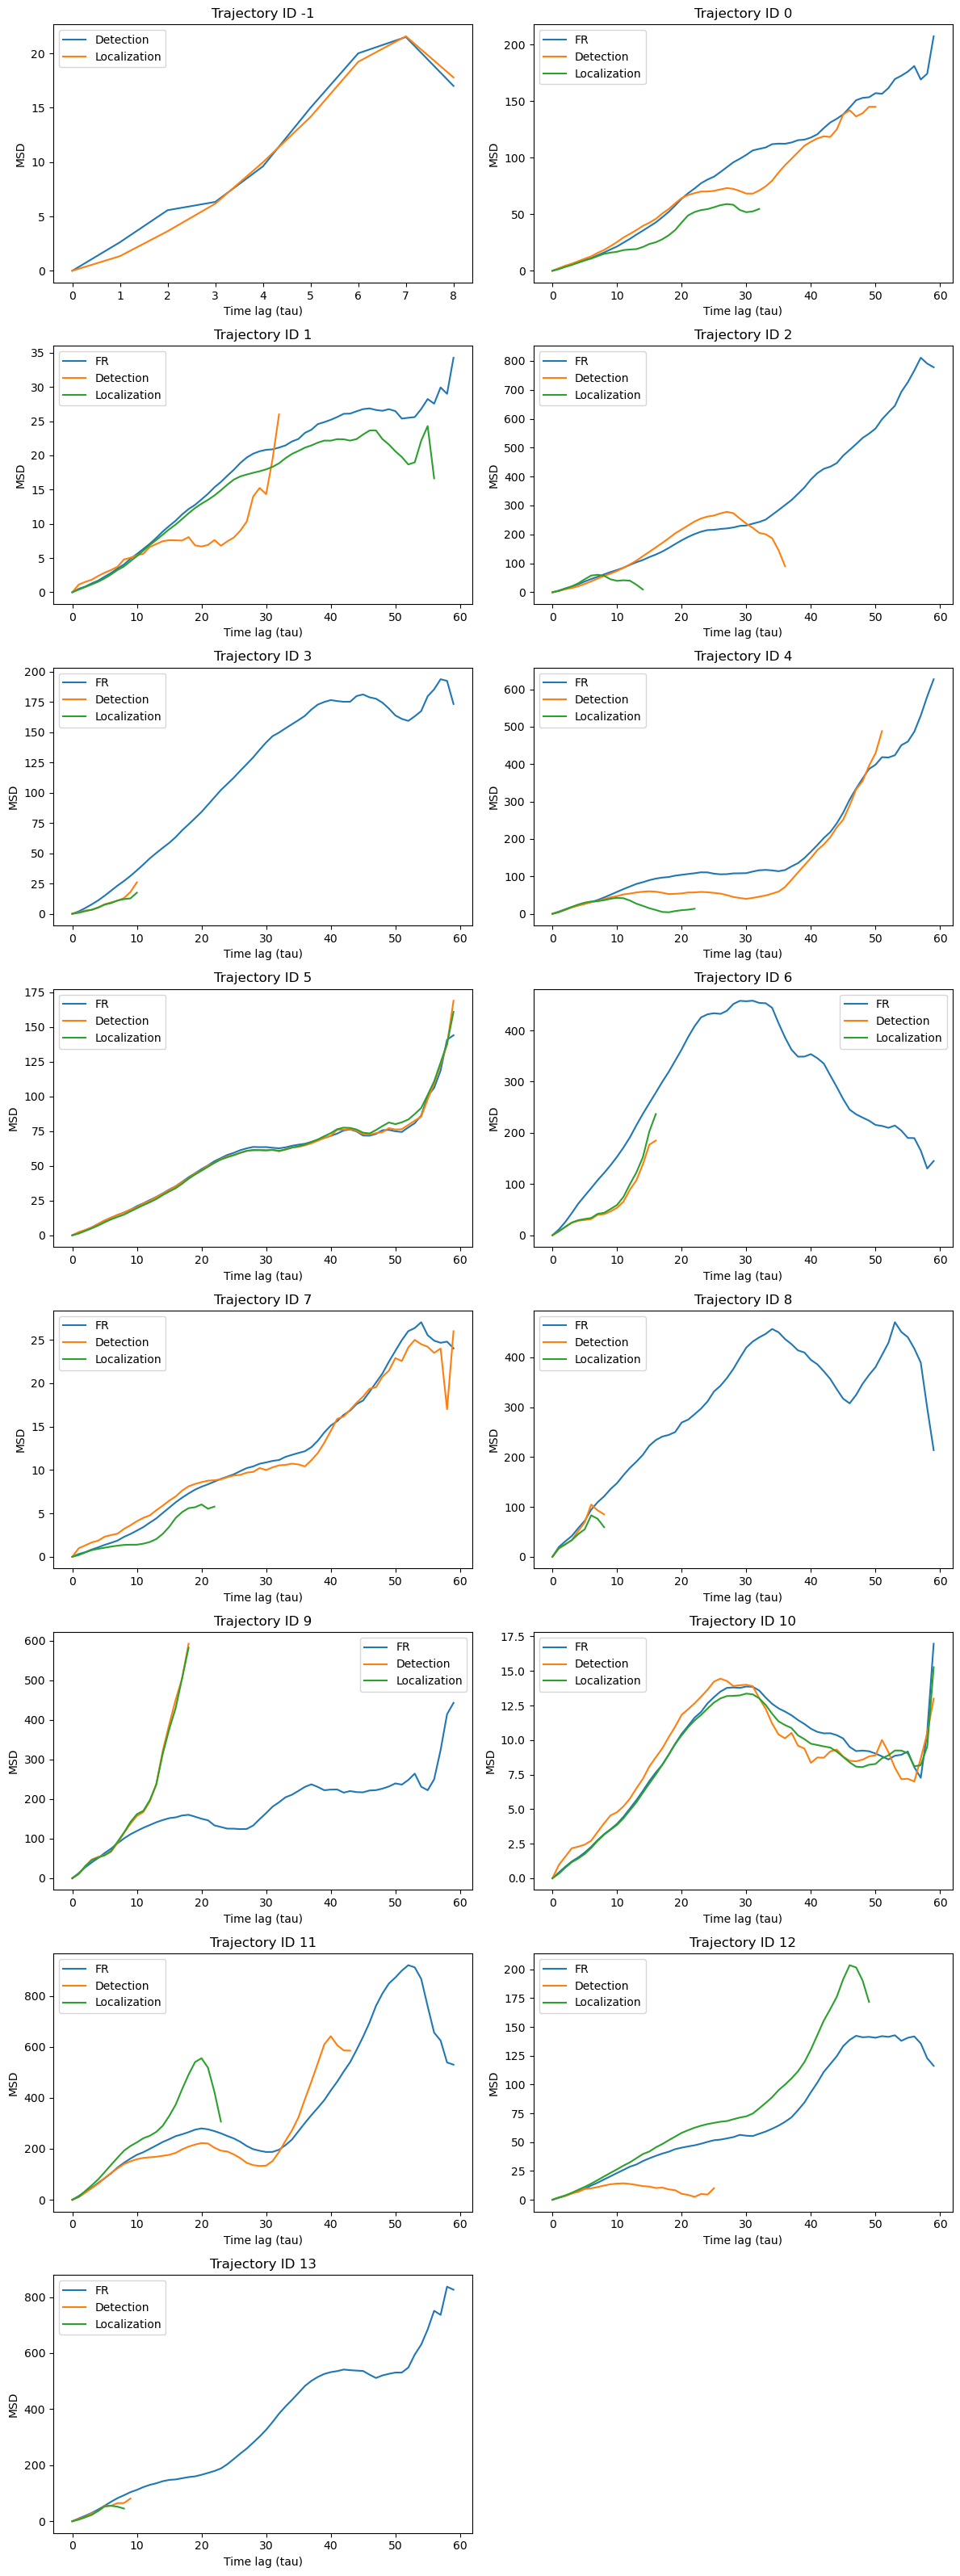

In [19]:
plotMSD_multi(traj_list[-3:], labels)